# Setup

In [464]:
# --- IMPORTS ---
import json
import tabulate
import matplotlib
import numpy as np
from pathlib import Path
from itertools import cycle
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.interpolate import interp1d
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# --- PATHS ---
cwd = Path.cwd()
fig_dir = cwd / 'figs'

# --- COLORS AND STYLES ---
_line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5, 1, 5)), (0, (5, 10))]
_line_colors = ['cornflowerblue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'olive', 'cyan']

_scatter_colors  = plt.get_cmap("Dark2").colors  # type: ignore
_scatter_markers = ['o', 's', '^', 'v', '<', '>', '*']

class Cycles:
    def __getattribute__(self, name: str) -> cycle:
        match name:
            case 'line_styles':
                return cycle(_line_styles)
            
            case 'line_colors':
                return cycle(_line_colors)
            
            case 'scatter_colors':
                return cycle(_scatter_colors)
            
            case 'scatter_markers':
                return cycle(_scatter_markers)
            
            case _:
                raise AttributeError(f'No such attribute as "{name}"')
            
            
cycles = Cycles()

In [465]:
def read_exfor_data(file_path: str | Path) -> dict[str, dict[str, float]]:
    """
    Reads EXFOR data from a JSON file and stores it in a structured dictionary.
    
    Parameters
    ----------
    file_path : str | Path
        Path to the JSON file containing EXFOR data.
    
    Returns
    ------- 
    dict[str, dict[str, float]]
        A dictionary where each key is an author's name and the value is another dictionary
        containing arrays for 'x', 'y', 'dy', and 'dx' data.
        
        x:  Energy values (MeV)
        
        y:  Cross section values (mb)
        
        dy: Uncertainties in y (mb)
        
        dx: Uncertainties in x (MeV)
    """
    with open(file_path) as file:
        exfor = json.load(file)
    
    data_exfor = {}
    for funcs in exfor['funcs']:
        data_set = funcs['pts']
        for entry in data_set:
            author = entry['a1']
            if author not in data_exfor:
                data_exfor[author] = {'x': [], 'y': [], 'dy': [], 'dx': []}
                
            data_exfor[author]['x'].append(entry['x'])
            data_exfor[author]['y'].append(entry['y'])
            
            if 'dy' in entry:
                data_exfor[author]['dy'].append(entry['dy']) 
            else:
                data_exfor[author]['dy'].append(np.nan)
            
            if 'dx' in entry:
                data_exfor[author]['dx'].append(entry['dx']) 
            else:
                data_exfor[author]['dx'].append(np.nan)
                
    for author in data_exfor:
        data_exfor[author]['x'] =     np.array(data_exfor[author]['x'])
        data_exfor[author]['y'] = 1e3*np.array(data_exfor[author]['y'])
        
        data_exfor[author]['dx'] = np.ma.masked_invalid(    np.array(data_exfor[author]['dx']))
        data_exfor[author]['dy'] = np.ma.masked_invalid(1e3*np.array(data_exfor[author]['dy']))
        
    return data_exfor


def plot_exfor_data(exfor_data: dict[str, dict[str, float]], face_alpha: float = 1, border_alpha: float = 1) -> None:
    """
    Plots EXFOR data from dict returned by `read_exfor_data()`. 
    
    Parameters
    ----------
    exfor_data : dict[str, dict[str, float]]
        A dictionary where each key is an author's name and the value is another dictionary containing arrays for 'x', 'y', 'dy', and 'dx' data.
        
        x:  Energy values (MeV)\n    
        y:  Cross section values (mb)\n    
        dy: Uncertainties in y (mb)\n    
        dx: Uncertainties in x (MeV)\n    
    face_alpha : float, optional
        Alpha value for the face of the markers (default is 1).
    border_alpha : float, optional
        Alpha value for the border of the markers (default is 1).
    """
    
    
    colors  = cycles.scatter_colors
    markers = cycles.scatter_markers
    for author in exfor_data: 
        x  = exfor_data[author]['x']
        y  = exfor_data[author]['y']
        dy = exfor_data[author]['dy']
        dx = exfor_data[author]['dx']
        
        fmt    = next(markers)
        color  = (*next(colors), face_alpha)
        
        # Plot error BARS only
        plt.errorbar(x, y, yerr=dy, xerr=dx, color=color, zorder=2, alpha=face_alpha, linestyle='none')
        
        # Plot data POINTS only on top of error bars
        plt.scatter(x, y, marker=fmt, zorder=3, edgecolor=(0,0,0,border_alpha), facecolor=color, label=author)
        
def plot_TALYS_data(file_path: str | Path, title: str, title_size: int = matplotlib.rcParams['axes.titlesize'], color: str | tuple[int, int, int] = 'blue', linestyle: str = '-', zorder: int = 3, logx: bool = False, logy: bool = True) -> None:
    """
    Plots TALYS data from a given file.
    
    Parameters
    ----------
    file_path : str | Path
        Path to the TALYS data file.
    title : str
        Title for the plot.
    title_size : int, optional
        Font size for the title (default is matplotlib.rcParams['axes.titlesize']).
    color : str | tuple[int, int, int]
        Color for the plot line (default is 'blue').
    linestyle : str, optional
        Line style for the plot (default is '-').
    zorder : int, optional
        Z-order for the plot (default is 3).
    logx : bool, optional
        Whether to use logarithmic scale for x-axis (default is False).
    logy : bool, optional
        Whether to use logarithmic scale for y-axis (default is True).
    """
    data = np.loadtxt(file_path, comments='#')
    E  = data[:, 0]
    CS = data[:, 1]
    
    plt.plot(E, CS, label='TALYS (default)', color=color, linestyle=linestyle, zorder=zorder)
    
    plt.xlabel('Energy [MeV]')
    plt.ylabel('Cross Section [mb]')
    if logx:
        plt.xscale('log')
    if logy:
        plt.yscale('log')
        
    plt.title(title, fontsize=title_size)
    plt.legend()
    

def plot_TALYS_band(varying_models_data: list[list[str]]) -> None:
    """
    Plots a band representing the range of TALYS cross sections from varying models.
    
    Parameters
    ----------
    varying_models_data : list[list[str]]
        A list of lists containing file paths to TALYS data files for different models.
    """
    varying_models_data_list = [np.loadtxt(file) for row in varying_models_data for file in row]

    min_cross_sections = np.min([data[:,1] for data in varying_models_data_list], axis=0)
    max_cross_sections = np.max([data[:,1] for data in varying_models_data_list], axis=0)
    median_cross_sections = np.median([data[:,1] for data in varying_models_data_list], axis=0)
    energies = varying_models_data_list[0][:,0]

    plt.plot(energies, median_cross_sections, color='blue', label='Median TALYS cross section')
    plt.fill_between(energies, min_cross_sections, max_cross_sections, color='blue', label='TALYS', alpha=0.3)
    
    plt.xlabel('Energy [MeV]')
    plt.ylabel('Cross section [mb]')


def ghost_legend() -> None:
    """
    Adds an invisible legend entry to create spacing in the legend.
    """
    plt.plot([], [], ' ', label = ' ')
    
    
def set_size(width=469.75502, fraction=1):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float
            Document textwidth or columnwidth in pts
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim



In [466]:
# --- MATPLOTLIB SETTINGS ---
matplotlib.rcParams.update({
    'font.size': 12,
    'figure.figsize': set_size(),
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'legend.fontsize': 8,
    'axes.grid': True,
    'savefig.format': 'pdf',
    # 'legend.facecolor': 'snow',
})

# Example 1

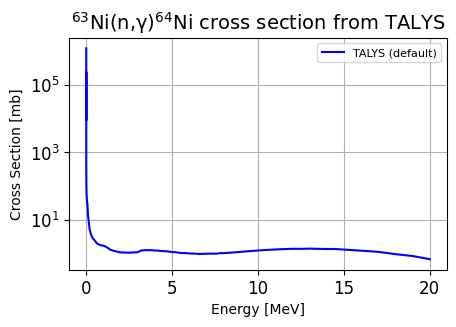

In [467]:
Ni63_n_γ = cwd / 'SimpleExampleEnergyGrid/rp028064.tot'

plt.figure(figsize=set_size(fraction=0.75))
plot_TALYS_data(Ni63_n_γ, title=r"$^{63}$Ni(n,γ)$^{64}$Ni cross section from TALYS")

plt.show()

# Exercise 1

## $^{191}\text{Os}$

### $(n,γ)$

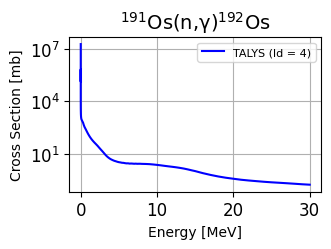

In [468]:
Os191_n_γ = cwd / 'Os191/default/rp076192.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Os191_n_γ, title=r"$^{191}$Os(n,γ)$^{192}$Os")

plt.legend(['TALYS (ld = 4)'])

plt.savefig(fig_dir / 'Os191_n_gamma_cross_section', bbox_inches='tight')
plt.show()

### $(n, n')$

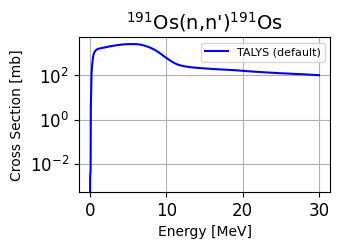

In [469]:
Os191_n_nprime = cwd / 'Os191/default/rp076191.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Os191_n_nprime, title=r"$^{191}$Os(n,n')$^{191}$Os")

plt.savefig(fig_dir / 'Os191_n_nprime_cross_section', bbox_inches='tight')
plt.show()

## $^{191}\text{Re}$

### $(p, γ)$

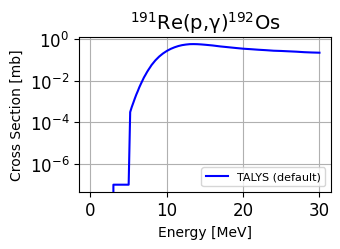

In [470]:
Re191_p_γ = cwd / 'Re191/rp076192.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Re191_p_γ, title=r"$^{191}$Re(p,γ)$^{192}$Os")

plt.savefig(fig_dir / 'Re191_p_gamma_cross_section', bbox_inches='tight')
plt.show()

# Example 2: $^{90}\text{Zr}(n, γ)$

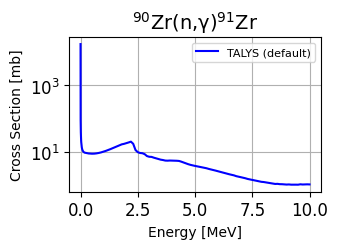

In [471]:
Zr90_n_γ = cwd / 'Zr90/rp040091.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Zr90_n_γ, title=r"$^{90}$Zr(n,γ)$^{91}$Zr")

plt.savefig(fig_dir / 'Zr90_n_gamma_cross_section', bbox_inches='tight')
plt.show()

## EXFOR Data Comparison
**Request Parameters**:
- Target: Zr-90
- Reaction: n,g
- Quantity: CS*

**Dataset Qualifiers**:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

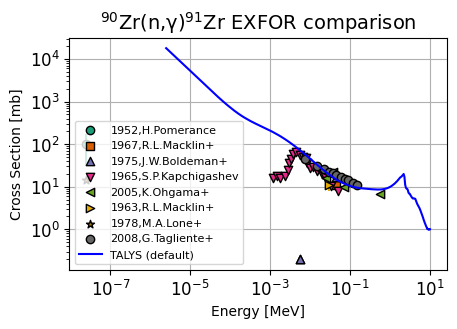

In [472]:
Zr90_exfor_data = read_exfor_data(cwd / 'Zr90/exfor_complete_data.json')

plt.figure(figsize=set_size(fraction=0.75))
plot_exfor_data(Zr90_exfor_data)    
plot_TALYS_data(Zr90_n_γ, title=r"$^{90}$Zr(n,γ)$^{91}$Zr EXFOR comparison", logx=True)

# plt.xlim(1e-3, 0.160)

plt.savefig(fig_dir / 'Zr90_n_gamma_cross_section_comparison_selected_data', bbox_inches='tight')
plt.show()

# Exercise 2: $^{208}\text{Pb}$

## $(n, n')$

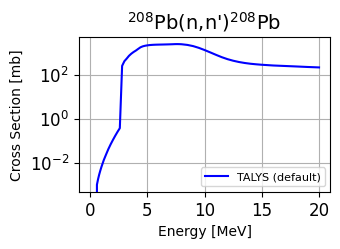

In [473]:
Pb208_n_nprime = cwd / 'Pb208/default/rp082208.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Pb208_n_nprime, title=r"$^{208}$Pb(n,n')$^{208}$Pb")

plt.savefig(fig_dir / 'Pb208_n_nprime_cross_section', bbox_inches='tight')
plt.show()


### EXFOR Data Comparison
**Request Parameters**:
- Target: Pb-208
- Reaction: n,inl
- Quantity: CS*

**Dataset Qualifiers**:
- MF = 3 (reaction cross sections)
- MT = 4 (inelastic)

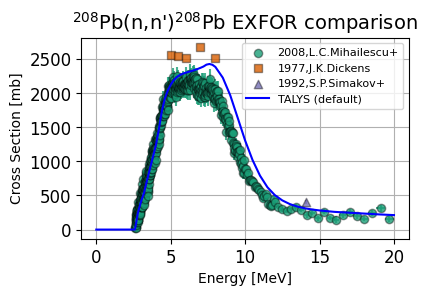

In [474]:
plt.figure(figsize=set_size(fraction=0.65))
Pb208_n_nprime_exfor_data = read_exfor_data(cwd / 'Pb208/exfor_n_nprime_complete_data.json')
plot_exfor_data(Pb208_n_nprime_exfor_data, face_alpha=0.8, border_alpha=0.4)
plot_TALYS_data(Pb208_n_nprime, title=r"$^{208}$Pb(n,n')$^{208}$Pb EXFOR comparison", logy=False)


plt.savefig(fig_dir / 'Pb208_n_nprime_inl_cross_section_comparison_complete_data', bbox_inches='tight')
plt.show()

## $(n, 2n)$

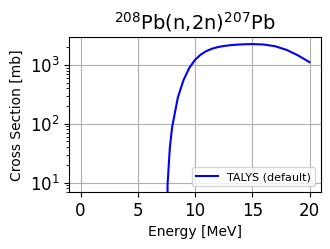

In [475]:
Pb208_n_2n = cwd / 'Pb208/default/rp082207.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Pb208_n_2n, title=r"$^{208}$Pb(n,2n)$^{207}$Pb")

plt.savefig(fig_dir / 'Pb208_n_2n_cross_section', bbox_inches='tight')
plt.show()

### EXFOR Data Comparison
**Request Parameters**:
- Target: Pb-208
- Reaction: n,2n
- Quantity: CS*

**Dataset Qualifiers**:
- MF = 3 (reaction cross sections)
- MT = 16 (2n)

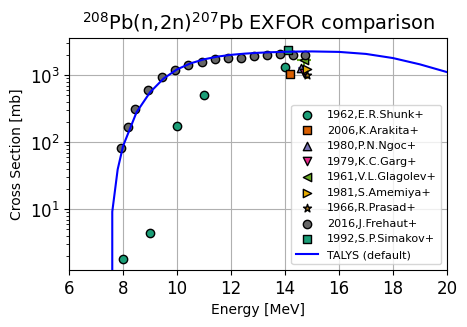

In [476]:
Pb208_n_2n_exfor_data = read_exfor_data(cwd / 'Pb208/exfor_n_2n_complete_data.json')

plt.figure(figsize=set_size(fraction=0.75))
plot_exfor_data(Pb208_n_2n_exfor_data)
plot_TALYS_data(Pb208_n_2n, title=r"$^{208}$Pb(n,2n)$^{207}$Pb EXFOR comparison")

plt.xlim(6, 20)

plt.savefig(fig_dir / 'Pb208_n_2n_cross_section_comparison_complete_data', bbox_inches='tight')
plt.show()

## $(n, γ)$

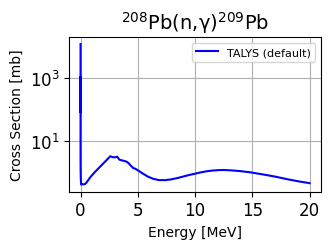

In [477]:
Pb208_n_γ = cwd / 'Pb208/default/rp082209.tot'

plt.figure(figsize=set_size(fraction=0.5))
plot_TALYS_data(Pb208_n_γ, title=r"$^{208}$Pb(n,γ)$^{209}$Pb")

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section', bbox_inches='tight')
plt.show() 

### EXFOR Data Comparison
**Request Parameters**:
- Target: Pb-208
- Reaction: n,g
- Quantity: CS*

**Dataset Qualifiers**:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

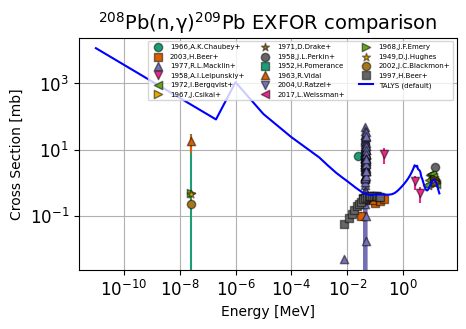

In [478]:
Pb208_n_γ_exfor_data = read_exfor_data(cwd / 'Pb208/exfor_n_g_complete_data.json')

plt.figure(figsize=set_size(fraction=0.75))
plot_exfor_data(Pb208_n_γ_exfor_data, border_alpha=0.5)
plot_TALYS_data(Pb208_n_γ, title=r"$^{208}$Pb(n,γ)$^{209}$Pb EXFOR comparison", logx=True)

plt.legend(ncols=3, fontsize=5)

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_comparison_complete_data', bbox_inches='tight')
plt.show()

# EXercise 3: $^{208}\text{Pb}(\text{n}, \gamma)$ Varying Models

**γ-ray strength function models**:
- strength 1: Kopecky-Uhl generalized Lorentzian
- strength 2: Brink-Axel Lorentzian
- strength 3: Hartree-Fock BCS tables
- strength 4: Hartree-Fock-Bogoliubov tables
- strength 5: Goriely’s hybrid model [48]
- strength 6: Goriely T-dependent HFB
- strength 7: T-dependent RMF
- strength 8: Gogny D1M HFB+QRPA
- strength 9: SMLO

**Level density models**:
- ldmodel 1: Constant Temperature + Fermi gas model (CTM)
- ldmodel 2: Back-shifted Fermi gas Model (BFM)
- ldmodel 3: Generalised Superfluid Model (GSM)
- ldmodel 4: Skyrme-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 5: Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 6: Temperature-dependent Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables

In [479]:
Pb208_n_γ_varying_models = [[cwd / f'Pb208/d{d}s{s}/rp082209.tot' for s in range(1,10)] for d in range(1,7)]

Pb208_n_γ_varying_models_data = {d: {s: {'E': np.loadtxt(file)[:,0], 'CS': np.loadtxt(file)[:,1]} for s, file in enumerate(row, start=1)} for d, row in enumerate(Pb208_n_γ_varying_models, start=1)}


Pb208_n_γ_best = cwd / 'Pb208' / 'best' / 'rp082209.tot'
Pb208_n_γ_best_data = np.loadtxt(Pb208_n_γ_best)

Pb208_n_γ_best_E  = Pb208_n_γ_best_data[:, 0]
Pb208_n_γ_best_CS = Pb208_n_γ_best_data[:, 1]

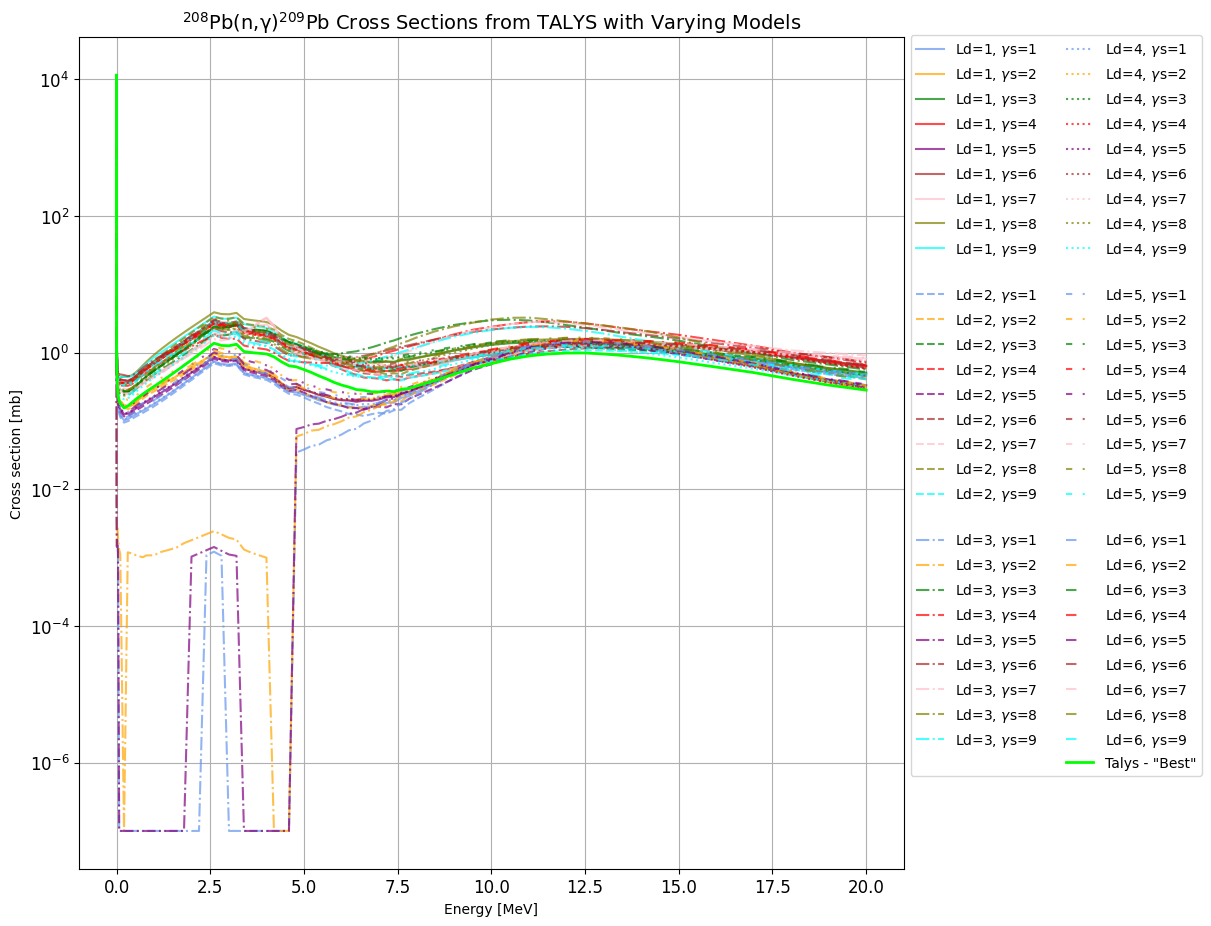

In [480]:
plt.figure(figsize = (12, 9.15), constrained_layout=True)

line_styles = cycles.line_styles
line_colors = cycles.line_colors
for d, row in enumerate(Pb208_n_γ_varying_models_data, start=1):
    linestyle = next(line_styles)
    for s in Pb208_n_γ_varying_models_data[d]:
        E  = Pb208_n_γ_varying_models_data[d][s]['E']
        CS = Pb208_n_γ_varying_models_data[d][s]['CS']
        
        color = next(line_colors)
        plt.plot(E, CS, label=f'Ld={d}, $γ$s={s}', linestyle=linestyle, alpha=0.7, color=color)
        
        # if (d == 2 and s == 9) or (d == 4 and s == 9):
        #     ghost_legend()
            
    if d != 6:
        ghost_legend()


plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Talys - "Best"', color='lime', linewidth=2, zorder=3)
# plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')
plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb Cross Sections from TALYS with Varying Models")
plt.legend(fontsize=10, ncols=2, bbox_to_anchor=(1, 1.011), loc='upper left')

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_varying_models', bbox_inches='tight')
plt.show()

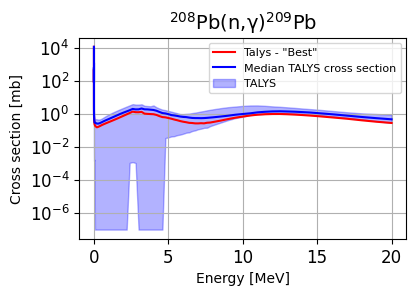

In [481]:
plt.figure(figsize=set_size(fraction=0.65))
plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Talys - "Best"', color='red')
plot_TALYS_band(Pb208_n_γ_varying_models)

plt.semilogy()

plt.legend()
plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb")
plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_varying_models_band', bbox_inches='tight')

## EXFOR Data Comparison
**Request Parameters**:
- Target: Pb-208
- Reaction: n,g
- Quantity: CS*

**Dataset Qualifiers**:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

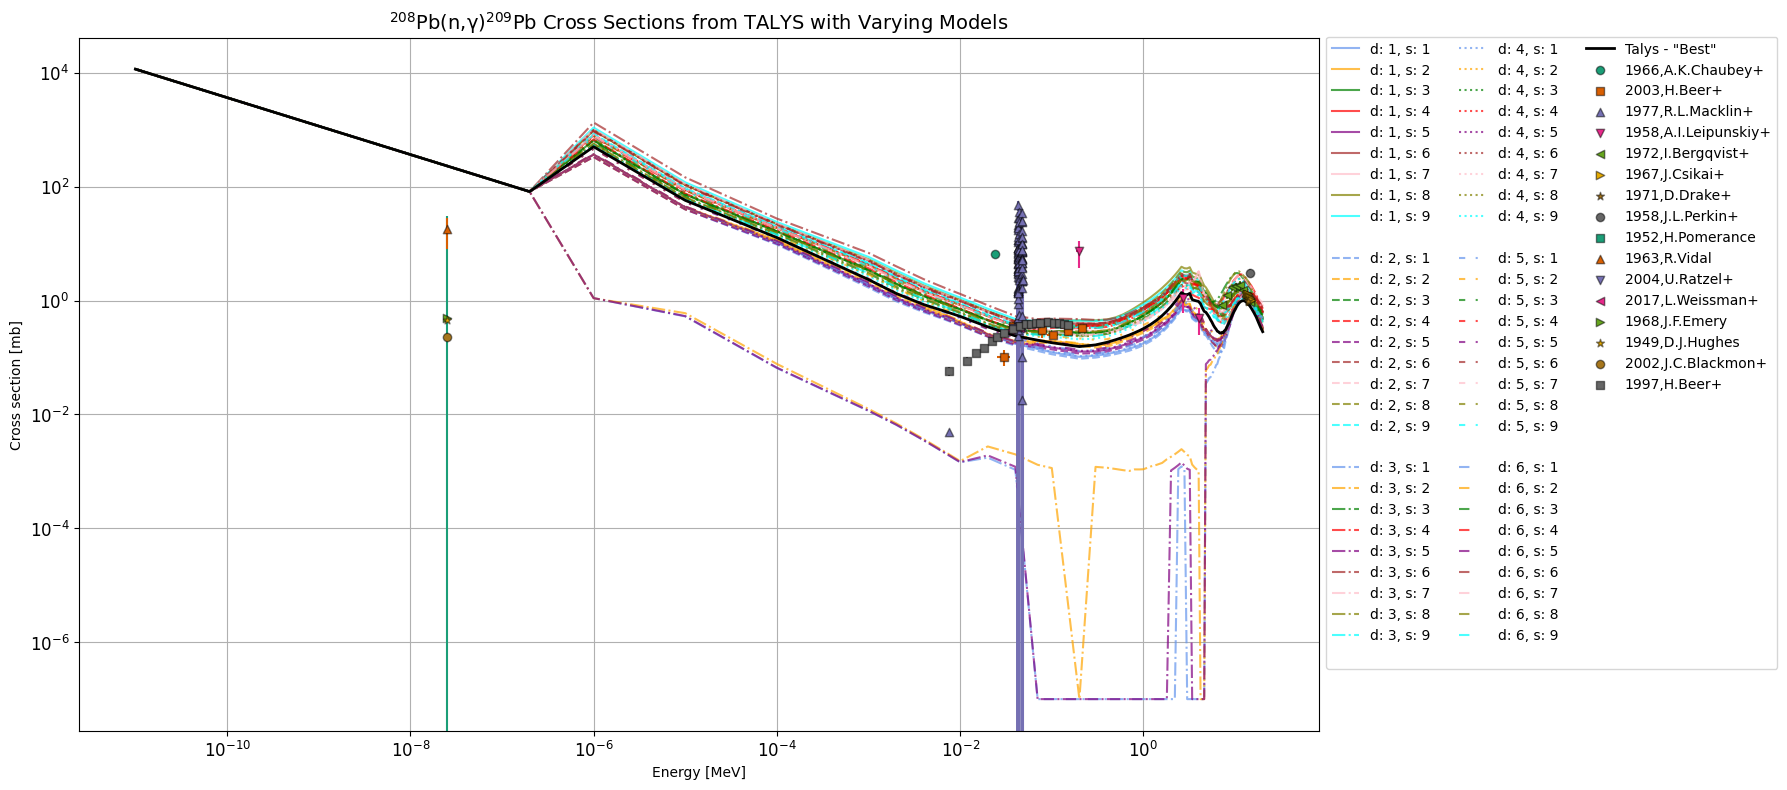

In [482]:
plt.figure(figsize=(16,9))

line_styles_cycle = cycle(line_styles)
line_colors_cycle = cycle(line_colors) 
for d, level_density_row in enumerate(Pb208_n_γ_varying_models_data, start=1):
    linestyle = next(line_styles_cycle)
    for s in Pb208_n_γ_varying_models_data[d]:
        E = Pb208_n_γ_varying_models_data[d][s]['E']
        CS = Pb208_n_γ_varying_models_data[d][s]['CS']
        
        color = next(line_colors_cycle)
        plt.plot(E, CS, label=f'd: {d}, s: {s}', alpha=0.7, linestyle=linestyle, color=color)
        
    # if d == 3:
    #     continue
    
    ghost_legend()

plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Talys - "Best"', color='black', linewidth=2, zorder=3)

plot_exfor_data(Pb208_n_γ_exfor_data, border_alpha=0.5)     

# Get current handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Add 13 spacers to the END
for _ in range(13):
    handles.append(plt.Line2D([], [], linestyle='None')) # type: ignore
    labels.append(' ')   

plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')
plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb Cross Sections from TALYS with Varying Models")
plt.legend(fontsize=10, ncols=3, bbox_to_anchor=(1,1.0115), handles=handles, labels=labels)

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_varying_models_with_exfor', bbox_inches='tight')
plt.show()

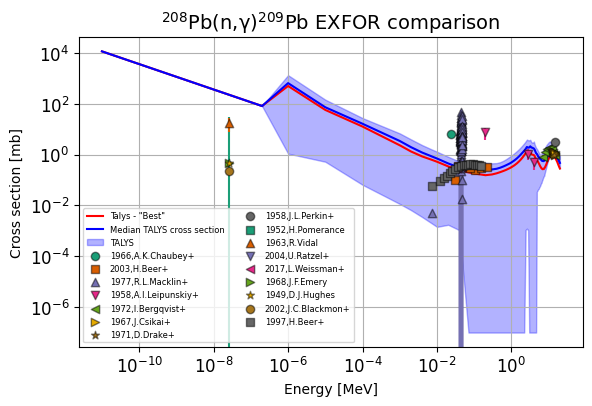

In [483]:
plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Talys - "Best"', color='red')
plot_TALYS_band(Pb208_n_γ_varying_models)
plot_exfor_data(Pb208_n_γ_exfor_data, border_alpha=0.5)
plt.legend(fontsize=6, ncols=2)

plt.semilogy()
plt.semilogx()

plt.title(r"$^{208}$Pb(n,γ)$^{209}$Pb EXFOR comparison")

plt.savefig(fig_dir / 'Pb208_n_gamma_cross_section_varying_models_band_with_exfor', bbox_inches='tight')
plt.show()

### Test Interpolation

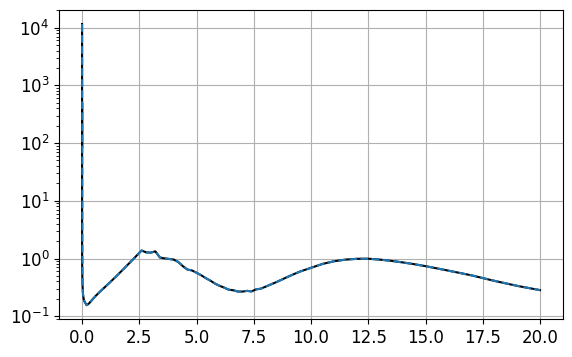

In [484]:
plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label='Talys - "Best"', color='black')

log_CS = np.log10(Pb208_n_γ_best_CS)
log_interp = interp1d(Pb208_n_γ_best_E, log_CS)

E_interpolated  = np.linspace(Pb208_n_γ_best_E.min(), Pb208_n_γ_best_E.max(), 1000)
CS_interpolated = 10**log_interp(E_interpolated)

plt.plot(E_interpolated, CS_interpolated, '--', label='Interpolated')
plt.semilogy()
# plt.semilogx()

plt.show()

### Fitting All Models

In [485]:
# Combine data from all EXFOR authors
E_exfor_all = np.array([])
CS_exfor_all = np.array([])
for author in Pb208_n_γ_exfor_data:
    if author == '1977,R.L.Macklin+':
        continue
    E_exfor  = Pb208_n_γ_exfor_data[author]['x']
    CS_exfor = Pb208_n_γ_exfor_data[author]['y']
    
    E_exfor_all  = np.concatenate((E_exfor_all, E_exfor))
    CS_exfor_all = np.concatenate((CS_exfor_all, CS_exfor))

### Finding the Optimal Model

In [486]:
mse_rankings = []
for d in Pb208_n_γ_varying_models_data:
    for s in Pb208_n_γ_varying_models_data[d]:
        E  = Pb208_n_γ_varying_models_data[d][s]['E']
        CS = Pb208_n_γ_varying_models_data[d][s]['CS']
        
        
        # Creating a log fit to be able to evaluate all EXFOR data points
        log_CS = np.log10(CS)
        log_interp = interp1d(E, log_CS, fill_value="extrapolate") # type: ignore
        
        CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
        
        # Filter out invalid values (zeros, negatives, NaNs)
        valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
                     np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)
        
        CS_model_valid = CS_model_at_exfor_energies[valid_mask]
        CS_exfor_valid = CS_exfor_all[valid_mask]
        
        if len(CS_model_valid) == 0:
            continue  # Skip if no valid points
        
        # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
        msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
        
        # 2. Mean Relative Error (MRE) - average relative deviation
        mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
        
        # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
        mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
        
        # 4. Root Mean Squared Log Error (RMSLE)
        rmsle = np.sqrt(msle)
        
        mse_rankings.append({'d': d, 's': s, 'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle})

# Calculating MSE for talys "best" model
# Creating a log fit to be able to evaluate all EXFOR data points
log_CS = np.log10(Pb208_n_γ_best_CS)
log_interp = interp1d(Pb208_n_γ_best_E, log_CS, fill_value="extrapolate") # type: ignore

CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
# Filter out invalid values (zeros, negatives, NaNs)
valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
             np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)
             
CS_model_valid = CS_model_at_exfor_energies[valid_mask]
CS_exfor_valid = CS_exfor_all[valid_mask]

talys_best_model_mse = {}
if len(CS_model_valid) != 0:
    # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
    msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
    
    # 2. Mean Relative Error (MRE) - average relative deviation
    mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
    
    # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
    mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
    
    # 4. Root Mean Squared Log Error (RMSLE)
    rmsle = np.sqrt(msle)
    
    talys_best_model_mse = {'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle}
    

# Sort by MSLE (best for log-scale) or MARE (most interpretable)
mse_rankings = sorted(mse_rankings, key=lambda x: x['msle'])
talys_best_model_rank = 1 + sum(1 for result in mse_rankings if result['msle'] < talys_best_model_mse['msle'])

print(f"TALYS 'best' model rank: {talys_best_model_rank}")
print(f'MSLE: {talys_best_model_mse["msle"]:.3e}, MRE: {talys_best_model_mse["mre"]:.3e}, MARE: {talys_best_model_mse["mare"]:.3e}, RMSLE: {talys_best_model_mse["rmsle"]:.3e}\n')

table = []
for rank, result in enumerate(mse_rankings, start=1):
    table.append([rank, result['d'], result['s'], f"{result['msle']:.3e}", f"{result['mre']:.3e}", f"{result['mare']:.3e}", f"{result['rmsle']:.3e}"])
    
headers = ["Rank", "Ld", "γs", "MSLE", "MRE", "MARE", "RMSLE"]
print(tabulate.tabulate(table, headers=headers, tablefmt="grid", disable_numparse=True))

TALYS 'best' model rank: 42
MSLE: 6.505e-01, MRE: 3.748e+01, MARE: 3.811e+01, RMSLE: 8.066e-01

+--------+------+------+-----------+-----------+-----------+-----------+
| Rank   | Ld   | γs   | MSLE      | MRE       | MARE      | RMSLE     |
+========+======+======+===========+===========+===========+===========+
| 1      | 4    | 8    | 6.104e-01 | 3.777e+01 | 3.810e+01 | 7.813e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 2      | 6    | 8    | 6.107e-01 | 3.794e+01 | 3.820e+01 | 7.815e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 3      | 5    | 3    | 6.109e-01 | 3.793e+01 | 3.817e+01 | 7.816e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 4      | 4    | 3    | 6.120e-01 | 3.792e+01 | 3.818e+01 | 7.823e-01 |
+--------+------+------+-----------+-----------+-----------+-----------+
| 5      | 6    | 3    | 6.121e-01 | 3.795e+01 | 3.819e+01 | 7.824e-01 |
+--------+------+------+----

### Plotting the Optimal Model

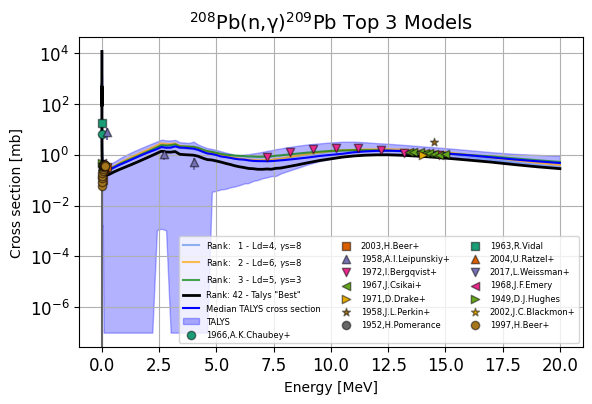

In [487]:
n = 3
colors = cycles.line_colors
for rank, model in enumerate(mse_rankings[: n], start=1):
    d = model['d']
    s = model['s']
    E = Pb208_n_γ_varying_models_data[d][s]['E']
    CS = Pb208_n_γ_varying_models_data[d][s]['CS']
    
    color = next(colors)
    plt.plot(E, CS, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7, color=color)

    
plt.plot(Pb208_n_γ_best_E, Pb208_n_γ_best_CS, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='black', linewidth=2, zorder=3)

plot_TALYS_band(Pb208_n_γ_varying_models)
Pb208_n_γ_exfor_data_no_macklin = {author: Pb208_n_γ_exfor_data[author] for author in Pb208_n_γ_exfor_data if author != '1977,R.L.Macklin+'}
plot_exfor_data(Pb208_n_γ_exfor_data_no_macklin, border_alpha=0.5)

# plt.semilogx()
plt.semilogy()
# plt.xlim(1.1, 20)
# plt.ylim(1e-1, 1e1)

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(f"{r"$^{208}$Pb(n,γ)$^{209}$Pb"} Top {n} Models")
plt.legend(ncols=3, fontsize=6)

plt.savefig(fig_dir / f'Pb208_n_gamma_cross_section_top_{n}_models_with_exfor', bbox_inches='tight')
plt.show()

# Exercise 4: $^{191}\text{Os}(n,γ)$

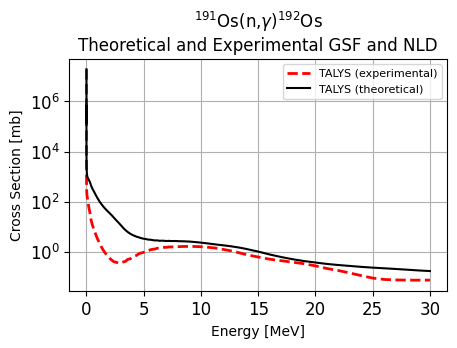

In [488]:
Os191_n_γ_experimental = cwd / 'Os191/exp/rp076192.tot'
Os191_n_γ_experimental_data = np.loadtxt(Os191_n_γ_experimental)

Os191_n_γ_experimental_E  = Os191_n_γ_experimental_data[:, 0]
Os191_n_γ_experimental_CS = Os191_n_γ_experimental_data[:, 1]

plt.figure(figsize=set_size(fraction=0.75))
plt.plot(Os191_n_γ_experimental_E, Os191_n_γ_experimental_CS, label='TALYS (experimental)', color='red', linewidth=2, linestyle='--')
plot_TALYS_data(Os191_n_γ, title=f"{r'$^{191}$Os(n,$γ$)$^{192}$Os'}\nTheoretical and Experimental GSF and NLD", title_size=12,color='black', linestyle='-')

plt.legend(['TALYS (experimental)', 'TALYS (theoretical)'])

plt.savefig(fig_dir / 'Os191_n_gamma_cross_section_experimental_data', bbox_inches='tight')
plt.show()

# Task: $^{119}\text{Sn}$(n,γ)

## Reaction Rates

### Default Model with JINA REACLIB Data Comparison

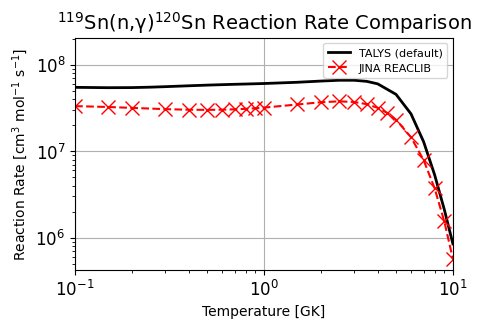

In [489]:
Sn119_n_γ_rr = cwd / 'Sn119/default/astrorate.g'
Sn119_n_γ_rr_data = np.loadtxt(Sn119_n_γ_rr)

Sn119_n_γ_rr_jina = cwd / 'Sn119/reaction_rates.txt'
Sn119_n_γ_rr_jina_data = np.loadtxt(Sn119_n_γ_rr_jina)

Sn119_n_γ_rr_T  = Sn119_n_γ_rr_data[:, 0]
Sn119_n_γ_rr_RR = Sn119_n_γ_rr_data[:, 1]

Sn119_n_γ_rr_jina_T  = Sn119_n_γ_rr_jina_data[:, 0]
Sn119_n_γ_rr_jina_RR = Sn119_n_γ_rr_jina_data[:, 1]

plt.figure(figsize=set_size(fraction=0.75))
plt.plot(Sn119_n_γ_rr_T, Sn119_n_γ_rr_RR, label='TALYS (default)', color='black', linewidth=2)
plt.plot(Sn119_n_γ_rr_jina_T, Sn119_n_γ_rr_jina_RR, 'rx--' ,label='JINA REACLIB', markersize=10)

plt.semilogx()
plt.semilogy()

plt.xlim(1e-1, 1e1)

plt.xlabel('Temperature [GK]')
plt.ylabel('Reaction Rate [cm$^3$ mol$^{-1}$ s$^{-1}$]')

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn Reaction Rate Comparison")
plt.legend()

plt.savefig(fig_dir / 'Sn119_n_gamma_reaction_rate_with_jina', bbox_inches='tight')
plt.show()

### Varying Models
**γ-ray strength function models**:
- strength 1: Kopecky-Uhl generalized Lorentzian
- strength 2: Brink-Axel Lorentzian
- strength 3: Hartree-Fock BCS tables
- strength 4: Hartree-Fock-Bogoliubov tables
- strength 5: Goriely’s hybrid model [48]
- strength 6: Goriely T-dependent HFB
- strength 7: T-dependent RMF
- strength 8: Gogny D1M HFB+QRPA
- strength 9: SMLO

**Level density models**:
- ldmodel 1: Constant Temperature + Fermi gas model (CTM)
- ldmodel 2: Back-shifted Fermi gas Model (BFM)
- ldmodel 3: Generalised Superfluid Model (GSM)
- ldmodel 4: Skyrme-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 5: Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 6: Temperature-dependent Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables

In [490]:
Sn119_n_γ_varying_models_astrorate = [[cwd / 'Sn119' / f'd{d}s{s}' / 'astrorate.g' for s in range(1,10)] for d in range(1,7)]

Sn119_n_γ_varying_models_astrorate_data = {d: {s: {'T': np.loadtxt(file)[:,0], 'RR': np.loadtxt(file)[:,1]} for s, file in enumerate(row, start=1)} for d, row in enumerate(Sn119_n_γ_varying_models_astrorate, start=1)}

Sn119_n_γ_best_astrorate = cwd / 'Sn119' / 'best' / 'astrorate.g'
Sn119_n_γ_best_astrorate_data = np.loadtxt(Sn119_n_γ_best_astrorate)

Sn119_n_γ_best_astrorate_T  = Sn119_n_γ_best_astrorate_data[:, 0]
Sn119_n_γ_best_astrorate_RR = Sn119_n_γ_best_astrorate_data[:, 1]

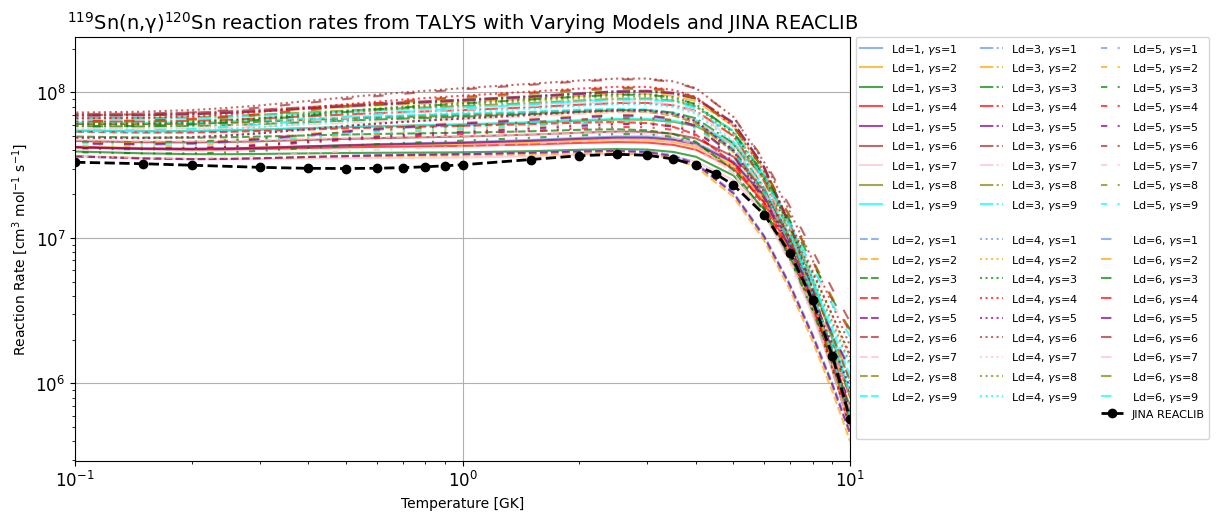

In [491]:
plt.figure(figsize=(10, 5.5))

line_styles = cycles.line_styles
line_colors = cycles.line_colors
for d, row in enumerate(Sn119_n_γ_varying_models_astrorate_data, start=1):
    linestyle = next(line_styles)
    for s in Sn119_n_γ_varying_models_astrorate_data[d]:
        temp      = Sn119_n_γ_varying_models_astrorate_data[d][s]['T']
        reac_rate = Sn119_n_γ_varying_models_astrorate_data[d][s]['RR']
        
        color = next(line_colors)
        plt.plot(temp, reac_rate, label=f'Ld={d}, $γ$s={s}', alpha=0.7, color=color, linestyle=linestyle)
        
    if (d == 2) or (d == 4):
        ghost_legend()
    
    if d != 6:
        ghost_legend()
        
Sn119_n_γ_rr_jina = cwd / 'Sn119/reaction_rates.txt'
Sn119_n_γ_rr_jina_data = np.loadtxt(Sn119_n_γ_rr_jina)

Sn119_n_γ_rr_jina_T  = Sn119_n_γ_rr_jina_data[:, 0]
Sn119_n_γ_rr_jina_RR = Sn119_n_γ_rr_jina_data[:, 1]

plt.plot(Sn119_n_γ_rr_jina_T, Sn119_n_γ_rr_jina_RR, 'o--', label='JINA REACLIB', color='black', linewidth=2)

plt.semilogx()
plt.semilogy()

plt.xlim(1e-1, 1e1)

plt.xlabel('Temperature [GK]')
plt.ylabel('Reaction Rate [cm$^3$ mol$^{-1}$ s$^{-1}$]')

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn reaction rates from TALYS with Varying Models and JINA REACLIB")

plt.legend(ncols=3, bbox_to_anchor=(0.9,0.89), bbox_transform=plt.gcf().transFigure)

plt.savefig(fig_dir / 'Sn119_n_gamma_reaction_rates_varying_models', bbox_inches='tight')
plt.show()

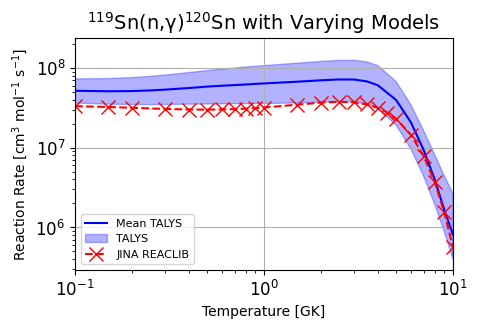

In [492]:
plt.figure(figsize=set_size(fraction=0.75))
plot_TALYS_band(Sn119_n_γ_varying_models_astrorate)


plt.plot(Sn119_n_γ_rr_jina_T, Sn119_n_γ_rr_jina_RR, label='JINA REACLIB', color='red', marker='x', linestyle='--', markersize=10)

plt.xlim(1e-1, 1e1)
plt.semilogx()
plt.semilogy()

plt.xlabel('Temperature [GK]')
plt.ylabel('Reaction Rate [cm$^3$ mol$^{-1}$ s$^{-1}$]')

plt.legend([
    'Mean TALYS',
    'TALYS',
    'JINA REACLIB'
])
plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn with Varying Models")

plt.savefig(fig_dir / 'Sn119_n_gamma_reaction_rates_varying_models_band_with_jina', bbox_inches='tight')

#### Finding the Optimal Model

In [493]:
mse_rankings = []
for d in Sn119_n_γ_varying_models_astrorate_data:
    for s in Sn119_n_γ_varying_models_astrorate_data[d]:
        T  = Sn119_n_γ_varying_models_astrorate_data[d][s]['T']
        RR = Sn119_n_γ_varying_models_astrorate_data[d][s]['RR']
        
        # Interpolating to JINA REACLIB temperatures
        log_RR = np.log10(RR)
        log_interp = interp1d(T, log_RR, fill_value="extrapolate") # type: ignore
        
        RR_model_at_jina_temperatures = 10**log_interp(Sn119_n_γ_rr_jina_T)
        
        # Filter out invalid values (zeros, negatives, NaNs)
        valid_mask = (RR_model_at_jina_temperatures > 0) & (Sn119_n_γ_rr_jina_RR > 0) & \
                     np.isfinite(RR_model_at_jina_temperatures) & np.isfinite(Sn119_n_γ_rr_jina_RR)
        RR_model_valid = RR_model_at_jina_temperatures[valid_mask]
        RR_jina_valid  = Sn119_n_γ_rr_jina_RR[valid_mask]
        
        if len(RR_model_valid) == 0:
            continue  # Skip if no valid points
        
        # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
        msle = np.mean((np.log10(RR_model_valid) - np.log10(RR_jina_valid))**2)
        
        # 2. Mean Relative Error (MRE) - average relative deviation
        mre = np.mean((RR_model_valid - RR_jina_valid) / RR_jina_valid)
        
        # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
        mare = np.mean(np.abs((RR_model_valid - RR_jina_valid) / RR_jina_valid))
        
        # 4. Root Mean Squared Log Error (RMSLE)
        rmsle = np.sqrt(msle)
        
        mse_rankings.append({'d': d, 's': s, 'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle})
        
# Calculating MSE for talys "best" model
T_best  = Sn119_n_γ_best_astrorate_T
RR_best = Sn119_n_γ_best_astrorate_RR

log_RR = np.log10(RR_best)
log_interp = interp1d(T_best, log_RR, fill_value="extrapolate") # type: ignore

RR_model_at_jina_temperatures = 10**log_interp(Sn119_n_γ_rr_jina_T)
# Filter out invalid values (zeros, negatives, NaNs)
valid_mask = (RR_model_at_jina_temperatures > 0) & (Sn119_n_γ_rr_jina_RR > 0) & \
             np.isfinite(RR_model_at_jina_temperatures) & np.isfinite(Sn119_n_γ_rr_jina_RR)

RR_model_valid = RR_model_at_jina_temperatures[valid_mask]
RR_jina_valid  = Sn119_n_γ_rr_jina_RR[valid_mask]

talys_best_model_mse = {}
if len(RR_model_valid) != 0:
    # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
    msle = np.mean((np.log10(RR_model_valid) - np.log10(RR_jina_valid))**2)
    
    # 2. Mean Relative Error (MRE) - average relative deviation
    mre = np.mean((RR_model_valid - RR_jina_valid) / RR_jina_valid)
    
    # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
    mare = np.mean(np.abs((RR_model_valid - RR_jina_valid) / RR_jina_valid))
    
    # 4. Root Mean Squared Log Error (RMSLE)
    rmsle = np.sqrt(msle)
    
    talys_best_model_mse = {'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle}

# Sort by MSLE (best for log-scale) or MARE (most interpretable)
mse_rankings = sorted(mse_rankings, key=lambda x: x['msle'])  
talys_best_model_rank = 1 + sum(1 for result in mse_rankings if result['msle'] < talys_best_model_mse['msle'])

print(f"TALYS 'best' model rank: {talys_best_model_rank}")
print(f'MSLE: {talys_best_model_mse["msle"]:.3e}, MRE: {talys_best_model_mse["mre"]:.3e}, MARE: {talys_best_model_mse["mare"]:.3e}, RMSLE: {talys_best_model_mse["rmsle"]:.3e}\n')

table = []
for rank, result in enumerate(mse_rankings, start=1):
    table.append([rank, result['d'], result['s'], f"{result['msle']:.3e}", f"{result['mre']:.3e}", f"{result['mare']:.3e}", f"{result['rmsle']:.3e}"])
    
headers = ["Rank", "Ld", "γs", "MSLE", "MRE", "MARE", "RMSLE"]
print(tabulate.tabulate(table, headers=headers, tablefmt="grid", disable_numparse=True))

TALYS 'best' model rank: 11
MSLE: 1.706e-02, MRE: 3.130e-01, MARE: 3.289e-01, RMSLE: 1.306e-01

+--------+------+------+-----------+------------+-----------+-----------+
| Rank   | Ld   | γs   | MSLE      | MRE        | MARE      | RMSLE     |
+========+======+======+===========+============+===========+===========+
| 1      | 1    | 7    | 2.719e-03 | 5.156e-02  | 1.039e-01 | 5.214e-02 |
+--------+------+------+-----------+------------+-----------+-----------+
| 2      | 1    | 3    | 5.464e-03 | 1.324e-01  | 1.718e-01 | 7.392e-02 |
+--------+------+------+-----------+------------+-----------+-----------+
| 3      | 5    | 7    | 9.268e-03 | 1.913e-01  | 2.308e-01 | 9.627e-02 |
+--------+------+------+-----------+------------+-----------+-----------+
| 4      | 2    | 1    | 9.584e-03 | 2.532e-02  | 1.730e-01 | 9.790e-02 |
+--------+------+------+-----------+------------+-----------+-----------+
| 5      | 2    | 5    | 1.034e-02 | 1.333e-02  | 1.724e-01 | 1.017e-01 |
+--------+------

#### Plotting the Optimal Model

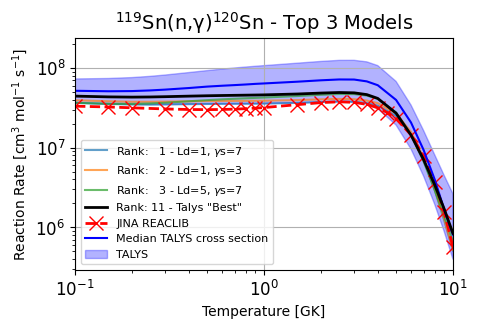

In [494]:
plt.figure(figsize=set_size(fraction=0.75))

n = 3
for rank, model in enumerate(mse_rankings[: n], start=1):
    d = model['d']
    s = model['s']
    T  = Sn119_n_γ_varying_models_astrorate_data[d][s]['T']
    RR = Sn119_n_γ_varying_models_astrorate_data[d][s]['RR']
    
    plt.plot(T, RR, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7)
    
plt.plot(Sn119_n_γ_best_astrorate_T, Sn119_n_γ_best_astrorate_RR, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='black', linewidth=2, zorder=3)
plt.plot(Sn119_n_γ_rr_jina_T, Sn119_n_γ_rr_jina_RR, 'x--', label='JINA REACLIB', color='red', linewidth=2, markersize=10)

plot_TALYS_band(Sn119_n_γ_varying_models_astrorate)

plt.semilogx()
plt.semilogy()

plt.xlim(1e-1, 1e1)

plt.xlabel('Temperature [GK]')
plt.ylabel('Reaction Rate [cm$^3$ mol$^{-1}$ s$^{-1}$]')

plt.title(f"{r"$^{119}$Sn(n,γ)$^{120}$Sn"} - Top {n} Models")
plt.legend()

plt.savefig(fig_dir / f'Sn119_n_gamma_reaction_rates_top_{n}_models_with_jina', bbox_inches='tight')
plt.show()

## Cross Sections

### Default Model with EXFOR Data Comparison
**Request Parameters**:
- Target: Sn-119
- Reaction: n,g
- Quantity: CS*

**Dataset Qualifiers**:
- MF = 3 (reaction cross sections)
- MT = 102 (γ)

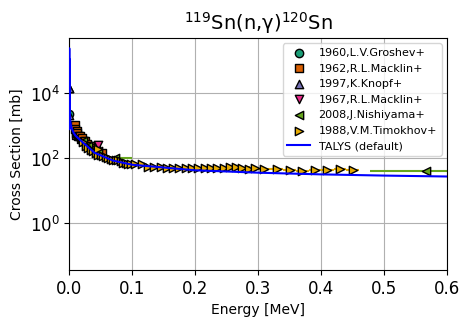

In [495]:
Sn119_n_γ = cwd / 'Sn119/default/rp050120.tot'
Sn119_n_γ_exp = cwd / 'Sn119/exp/rp050120.tot'
Sn119_n_γ_exfor_data = read_exfor_data(cwd / 'Sn119/exfor_complete_data.json')

plt.figure(figsize=set_size(fraction=0.75))
plot_exfor_data(Sn119_n_γ_exfor_data)
plot_TALYS_data(Sn119_n_γ_exp, title=r"$^{119}$Sn(n,γ)$^{120}$Sn")
plt.xlim(0, 0.6)

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_with_exfor', bbox_inches='tight')
plt.show()

### Varying Models
**γ-ray strength function models**:
- strength 1: Kopecky-Uhl generalized Lorentzian
- strength 2: Brink-Axel Lorentzian
- strength 3: Hartree-Fock BCS tables
- strength 4: Hartree-Fock-Bogoliubov tables
- strength 5: Goriely’s hybrid model [48]
- strength 6: Goriely T-dependent HFB
- strength 7: T-dependent RMF
- strength 8: Gogny D1M HFB+QRPA
- strength 9: SMLO

**Level density models**:
- ldmodel 1: Constant Temperature + Fermi gas model (CTM)
- ldmodel 2: Back-shifted Fermi gas Model (BFM)
- ldmodel 3: Generalised Superfluid Model (GSM)
- ldmodel 4: Skyrme-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 5: Gogny-Hartree-Fock-Bogoluybov level densities from numerical tables
- ldmodel 6: Temperature-dependent Gogny-Hartree-Fock-Bogoluybov level densities from
- numerical tables

In [496]:
Sn119_n_γ_varying_models = [[cwd / 'Sn119' / f'd{d}s{s}' / 'rp050120.tot' for s in range(1,10)] for d in range(1,7)]

Sn119_n_γ_varying_models_data = {d: {s: {'E': np.loadtxt(file)[:,0], 'CS': np.loadtxt(file)[:,1]} for s, file in enumerate(row, start=1)} for d, row in enumerate(Sn119_n_γ_varying_models, start=1)}

Sn119_n_γ_best = cwd / 'Sn119' / 'best' / 'rp050120.tot'
Sn119_n_γ_best_data = np.loadtxt(Sn119_n_γ_best)

Sn119_n_γ_best_E  = Sn119_n_γ_best_data[:, 0]
Sn119_n_γ_best_CS = Sn119_n_γ_best_data[:, 1]

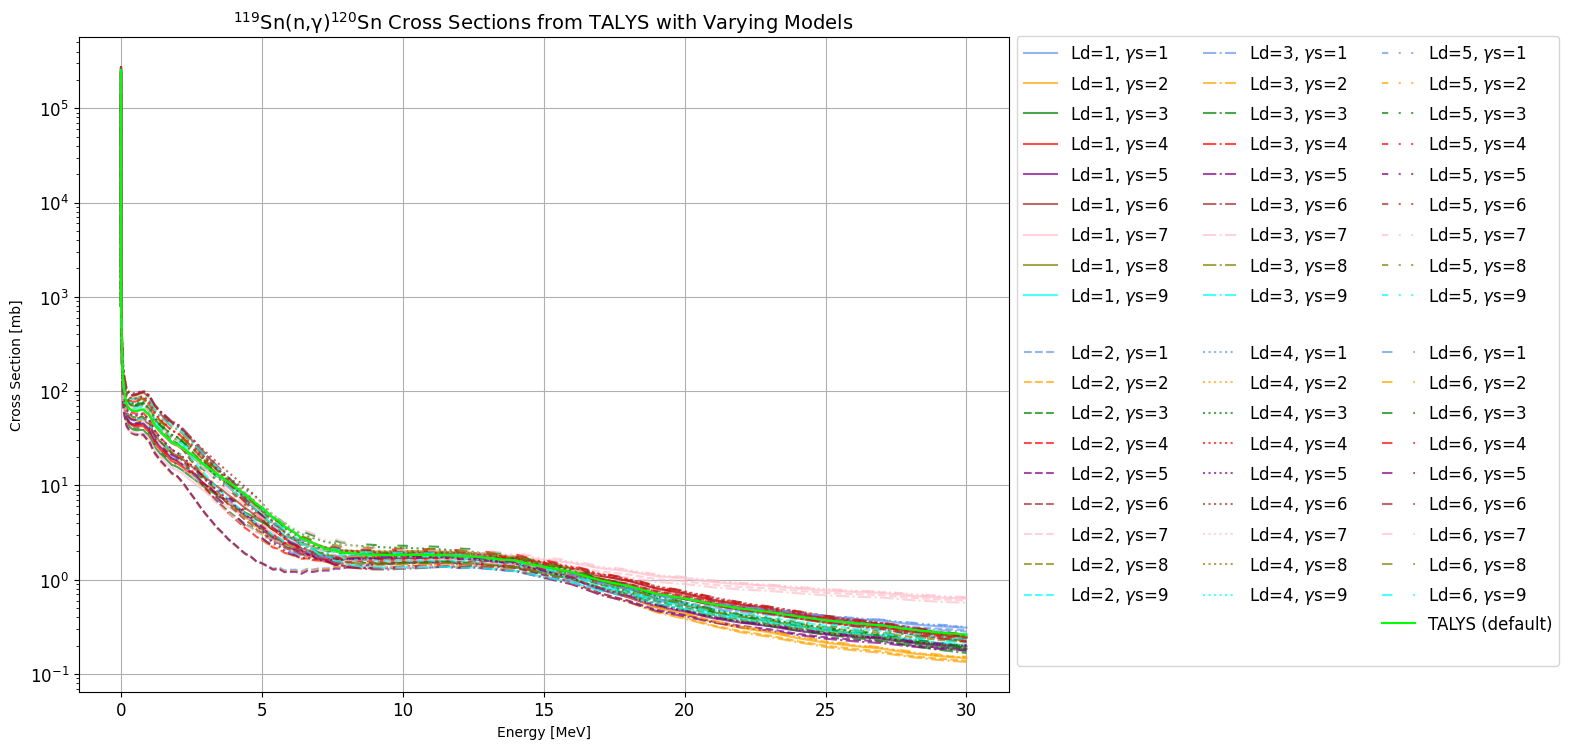

In [497]:
styles = cycles.line_styles
colors = cycles.line_colors

plt.figure(figsize = (12, 8.5))
for d, row in enumerate(Sn119_n_γ_varying_models_data, start=1):
    style = next(styles)
    for s in Sn119_n_γ_varying_models_data[d]:
        E  = Sn119_n_γ_varying_models_data[d][s]['E']
        CS = Sn119_n_γ_varying_models_data[d][s]['CS']
        
        color = next(colors)
        plt.plot(E, CS, label=f'Ld={d}, $γ$s={s}', linestyle=style, alpha=0.7, color=color)
        
    if (d == 2) or (d == 4):
        ghost_legend()
        
    if d != 6:
        ghost_legend()


plot_TALYS_data(Sn119_n_γ, title=r"$^{119}$Sn(n,γ)$^{120}$Sn Cross Sections from TALYS with Varying Models", color='lime')

plt.legend(fontsize=12, ncols=3, bbox_to_anchor=(1,1.015))
plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models')
plt.show()

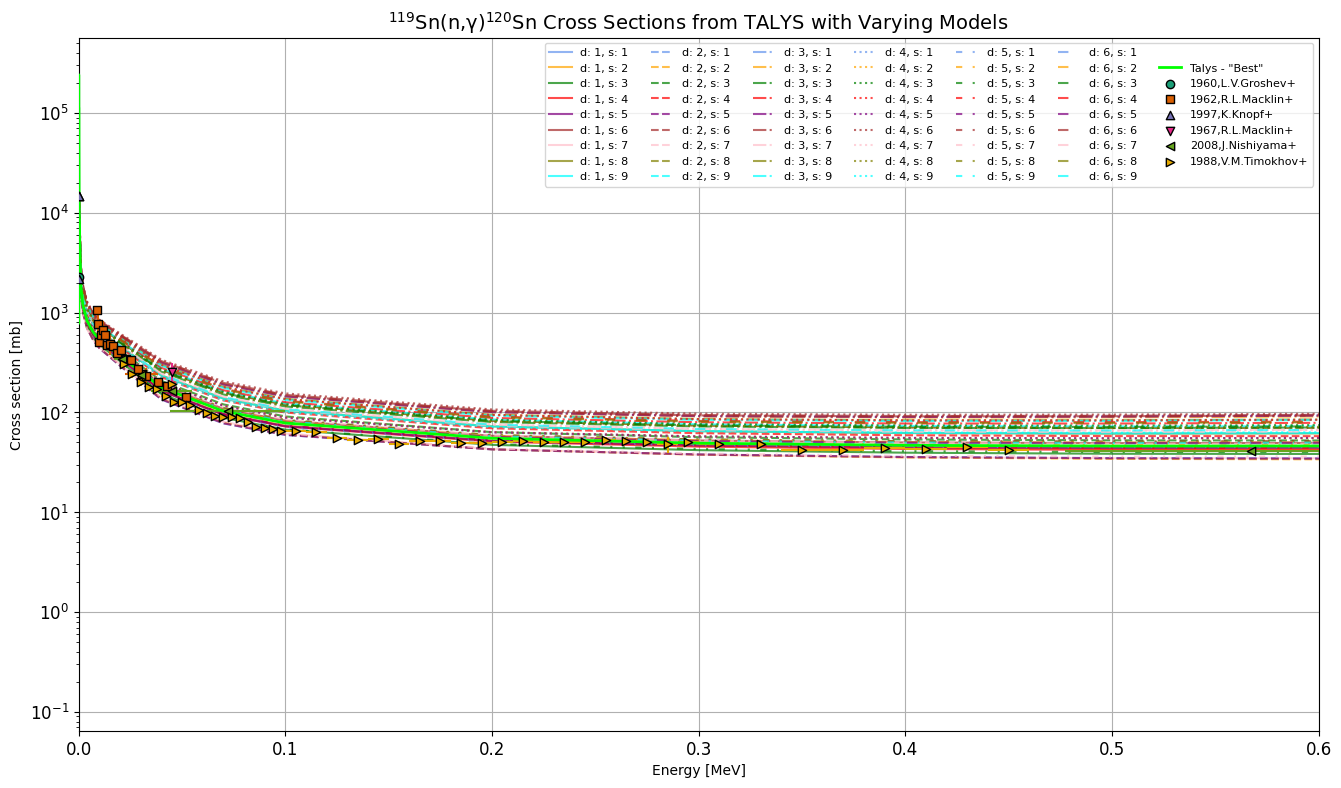

In [498]:
plt.figure(figsize=(16,9))
styles = cycles.line_styles
colors = cycles.line_colors
for d, level_density_row in enumerate(Sn119_n_γ_varying_models_data, start=1):
    style = next(styles)
    for s in Sn119_n_γ_varying_models_data[d]:
        E = Sn119_n_γ_varying_models_data[d][s]['E']
        CS = Sn119_n_γ_varying_models_data[d][s]['CS']
        
        color = next(colors)
        plt.plot(E, CS, label=f'd: {d}, s: {s}', alpha=0.7, linestyle=style, color=color)
    
    if d == 6:
        ghost_legend()
           
plt.plot(Sn119_n_γ_best_E, Sn119_n_γ_best_CS, label='Talys - "Best"', color='lime', linewidth=2, zorder=3)
plot_exfor_data(Sn119_n_γ_exfor_data)

# plt.semilogx()
plt.semilogy()
plt.xlim(0, 0.6)

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')
plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn Cross Sections from TALYS with Varying Models")
plt.legend(ncols=7)

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models_with_exfor')
plt.show()

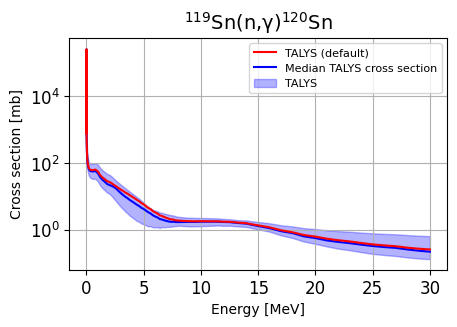

In [499]:
plt.figure(figsize=set_size(fraction=0.75))

plot_TALYS_data(Sn119_n_γ, title=r"$^{119}$Sn(n,γ)$^{120}$Sn", color='red')
plot_TALYS_band(Sn119_n_γ_varying_models)

plt.legend()
plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models_band', bbox_inches='tight')
plt.show()

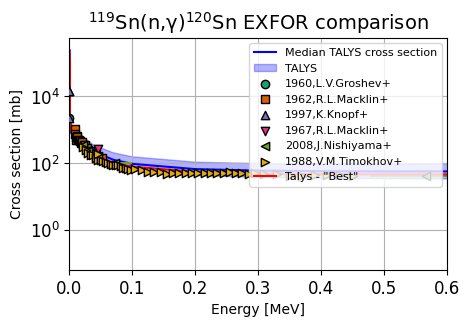

In [500]:
plt.figure(figsize=set_size(fraction=0.75))
plot_TALYS_band(Sn119_n_γ_varying_models)
plot_exfor_data(Sn119_n_γ_exfor_data)
plt.plot(Sn119_n_γ_best_E, Sn119_n_γ_best_CS, label='Talys - "Best"', color='red')
plt.legend()
# plt.semilogx()
plt.semilogy()
plt.xlim(0, 0.6)

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn EXFOR comparison")

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models_band_with_exfor', bbox_inches='tight')
plt.show()

#### Finding the Optimal Model

In [501]:
# Combine data from all EXFOR authors
E_exfor_all = np.array([])
CS_exfor_all = np.array([])
for author in Sn119_n_γ_exfor_data:
    E_exfor  = Sn119_n_γ_exfor_data[author]['x']
    CS_exfor = Sn119_n_γ_exfor_data[author]['y']
    
    E_exfor_all  = np.concatenate((E_exfor_all, E_exfor))
    CS_exfor_all = np.concatenate((CS_exfor_all, CS_exfor))

In [502]:
mse_rankings = []
for d in Sn119_n_γ_varying_models_data:
    for s in Sn119_n_γ_varying_models_data[d]:
        E = Sn119_n_γ_varying_models_data[d][s]['E']
        CS = Sn119_n_γ_varying_models_data[d][s]['CS']
        
        
        # Creating a log fit to be able to evaluate all EXFOR data points
        log_CS = np.log10(CS)
        log_interp = interp1d(E, log_CS, fill_value="extrapolate") # type: ignore
        
        CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
        
        # Filter out invalid values (zeros, negatives, NaNs)
        valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
                     np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)
        CS_model_valid = CS_model_at_exfor_energies[valid_mask]
        CS_exfor_valid = CS_exfor_all[valid_mask]
        
        if len(CS_model_valid) == 0:
            continue  # Skip if no valid points
        
        # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
        msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
        
        # 2. Mean Relative Error (MRE) - average relative deviation
        mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
        
        # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
        mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
        
        # 4. Root Mean Squared Log Error (RMSLE)
        rmsle = np.sqrt(msle)
        
        mse_rankings.append({'d': d, 's': s, 'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle})

# Calculating MSE for talys "best" model
E_best  = Sn119_n_γ_best_data[:, 0]
CS_best = Sn119_n_γ_best_data[:, 1]

# Creating a log fit to be able to evaluate all EXFOR data points
log_CS = np.log10(CS_best)
log_interp = interp1d(E_best, log_CS, fill_value="extrapolate") # type: ignore

CS_model_at_exfor_energies = 10**log_interp(E_exfor_all)
# Filter out invalid values (zeros, negatives, NaNs)
valid_mask = (CS_model_at_exfor_energies > 0) & (CS_exfor_all > 0) & \
             np.isfinite(CS_model_at_exfor_energies) & np.isfinite(CS_exfor_all)    

CS_model_valid = CS_model_at_exfor_energies[valid_mask]
CS_exfor_valid = CS_exfor_all[valid_mask]

talys_best_model_mse = {}
if len(CS_model_valid) != 0:
    # 1. Mean Squared Log Error (MSLE) - penalizes relative errors in log space
    msle = np.mean((np.log10(CS_model_valid) - np.log10(CS_exfor_valid))**2)
    
    # 2. Mean Relative Error (MRE) - average relative deviation
    mre = np.mean((CS_model_valid - CS_exfor_valid) / CS_exfor_valid)
    
    # 3. Mean Absolute Relative Error (MARE) - average magnitude of relative error
    mare = np.mean(np.abs((CS_model_valid - CS_exfor_valid) / CS_exfor_valid))
    
    # 4. Root Mean Squared Log Error (RMSLE)
    rmsle = np.sqrt(msle)
    
    talys_best_model_mse = {'msle': msle, 'mre': mre, 'mare': mare, 'rmsle': rmsle}


# Sort by MSLE (best for log-scale) or MARE (most interpretable)
mse_rankings = sorted(mse_rankings, key=lambda x: x['msle'])
talys_best_model_rank = 1 + sum(1 for result in mse_rankings if result['msle'] < talys_best_model_mse['msle'])

print(f"TALYS 'best' model rank: {talys_best_model_rank}")
print(f'MSLE: {talys_best_model_mse["msle"]:.3e}, MRE: {talys_best_model_mse["mre"]:.3e}, MARE: {talys_best_model_mse["mare"]:.3e}, RMSLE: {talys_best_model_mse["rmsle"]:.3e}\n')


table = []
for rank, result in enumerate(mse_rankings, start=1):
    table.append([rank, result['d'], result['s'], f"{result['msle']:.3e}", f"{result['mre']:.3e}", f"{result['mare']:.3e}", f"{result['rmsle']:.3e}"])

headers = ["Rank", "Ld", "γs", "MSLE", "MRE", "MARE", "RMSLE"]
print(tabulate.tabulate(table, headers=headers, tablefmt="grid", disable_numparse=True))

TALYS 'best' model rank: 8
MSLE: 2.293e-02, MRE: 2.081e-01, MARE: 2.772e-01, RMSLE: 1.514e-01

+--------+------+------+-----------+------------+-----------+-----------+
| Rank   | Ld   | γs   | MSLE      | MRE        | MARE      | RMSLE     |
+========+======+======+===========+============+===========+===========+
| 1      | 1    | 2    | 2.234e-02 | 1.533e-01  | 2.564e-01 | 1.495e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 2      | 1    | 4    | 2.237e-02 | 1.344e-01  | 2.526e-01 | 1.496e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 3      | 1    | 5    | 2.239e-02 | 1.460e-01  | 2.546e-01 | 1.496e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 4      | 1    | 1    | 2.244e-02 | 1.421e-01  | 2.537e-01 | 1.498e-01 |
+--------+------+------+-----------+------------+-----------+-----------+
| 5      | 5    | 4    | 2.254e-02 | 1.473e-01  | 2.562e-01 | 1.501e-01 |
+--------+------+

#### Plotting the Optimal Model

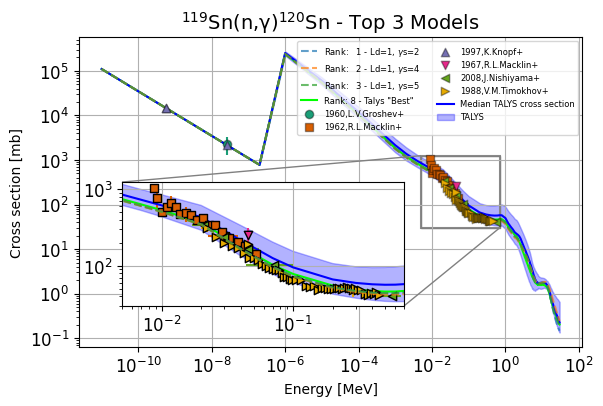

In [503]:
n = 3
for rank, model in enumerate(mse_rankings[: n], start=1):
    d = model['d']
    s = model['s']
    E = Sn119_n_γ_varying_models_data[d][s]['E']
    CS = Sn119_n_γ_varying_models_data[d][s]['CS']
    plt.plot(E, CS, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7, linestyle='--', zorder=3)

plt.plot(E_best, CS_best, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='lime', zorder=2)
plot_exfor_data(Sn119_n_γ_exfor_data, border_alpha=0.4)
plot_TALYS_band(Sn119_n_γ_varying_models)

plt.semilogx()
plt.semilogy()

plt.xlabel('Energy [MeV]')
plt.ylabel('Cross section [mb]')

plt.title(f"{r"$^{119}$Sn(n,γ)$^{120}$Sn"} - Top {n} Models")
plt.legend(ncols=2, fontsize=6, loc='upper right')


# Region to zoom
x0, x1 = 5e-3, 7e-1
y0, y1 = 3e1 , 1.25e3

# Draw zoom box on main axes
rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec='gray', lw=1.5, alpha=0.9)
ax = plt.gca()
ax.add_patch(rect)

axins = inset_axes(ax, width="40%", height="40%", loc="upper left", bbox_to_anchor=(0.075, -0.45, 1.4, 1), bbox_transform=ax.transAxes)

# ------------------ Begin Inner Plot ------------------
plt.sca(axins)

plot_exfor_data(Sn119_n_γ_exfor_data)
for rank, model in enumerate(mse_rankings[: n], start=1):
    d = model['d']
    s = model['s']
    E = Sn119_n_γ_varying_models_data[d][s]['E']
    CS = Sn119_n_γ_varying_models_data[d][s]['CS']
    plt.plot(E, CS, label=f'Rank:{rank:>4} - Ld={d}, $γ$s={s}', alpha=0.7, linestyle='--', zorder=3)
    
plt.plot(E_best, CS_best, label=f'Rank: {talys_best_model_rank} - Talys "Best"', color='lime', zorder=2)
plot_TALYS_band(Sn119_n_γ_varying_models)
plt.xlabel('')
plt.ylabel('')

axins.set_xscale('log')
axins.set_yscale('log')
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.grid(True)

plt.sca(ax)
# ------------------- End Inner Plot -------------------

# Connector lines
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='gray', lw=1)


plt.savefig(fig_dir / f'Sn119_n_gamma_cross_section_top_{n}_models_with_exfor')
plt.show()

### Experimental $γ$-ray Strength Function

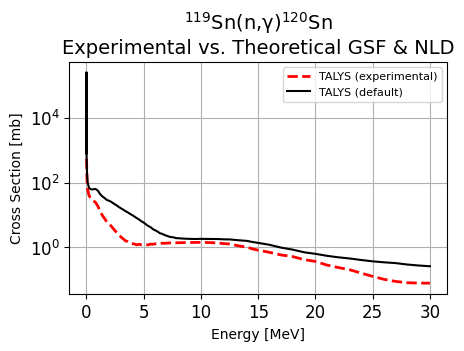

In [513]:
Sn119_n_γ_exp = cwd / 'Sn119/exp/rp050120.tot'
Sn119_n_γ_exp_data = np.loadtxt(Sn119_n_γ_exp)

Sn119_n_γ_exp_E  = Sn119_n_γ_exp_data[:, 0]
Sn119_n_γ_exp_CS = Sn119_n_γ_exp_data[:, 1]

plt.figure(figsize=set_size(fraction=0.75))
plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, label='TALYS (experimental)', color='red', linewidth=2, linestyle='--')
plot_TALYS_data(Sn119_n_γ, title=f"{r"$^{119}$Sn(n,γ)$^{120}$Sn"}\nExperimental vs. Theoretical GSF & NLD", color='black')

plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_experimental_data', bbox_inches='tight')
plt.show()

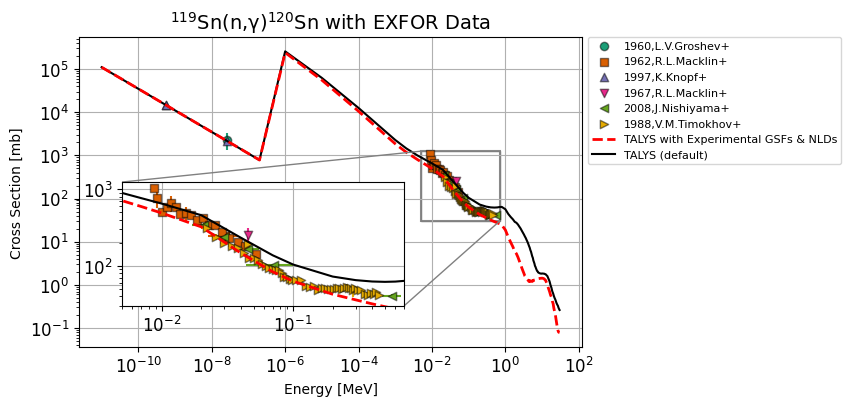

In [ ]:
Sn119_n_γ_exfor = cwd / 'Sn119/exfor_complete_data.json'
Sn119_n_γ_exfor_data = read_exfor_data(Sn119_n_γ_exfor)

plot_exfor_data(Sn119_n_γ_exfor_data, border_alpha=0.5)
plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, label='TALYS (Experimental)', color='red', linestyle='--', linewidth=2, zorder=4)
plot_TALYS_data(Sn119_n_γ, title=r"$^{119}$Sn(n,γ)$^{120}$Sn with EXFOR Data", color='black', logx=True)

# Region to zoom
x0, x1 = 5e-3, 7e-1
y0, y1 = 3e1 , 1.25e3

# Draw zoom box on main axes
rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec='gray', lw=1.5, alpha=0.9)
ax = plt.gca()
ax.add_patch(rect)

axins = inset_axes(ax, width="40%", height="40%", loc="upper left", bbox_to_anchor=(0.075, -0.45, 1.4, 1), bbox_transform=ax.transAxes)

# ------------------ Begin Inner Plot ------------------
plt.sca(axins)

plot_exfor_data(Sn119_n_γ_exfor_data, border_alpha=0.5)
plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, color='red', linestyle='--', linewidth=2, zorder=4)
plot_TALYS_data(Sn119_n_γ, title="", color='black', logx=True)

axins.set_xscale('log')
axins.set_yscale('log')
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.grid(True)
axins.get_legend().remove()
axins.set_xlabel('')
axins.set_ylabel('')

plt.sca(ax)
# ------------------- End Inner Plot -------------------

# Connector lines
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='gray', lw=1)


plt.legend(bbox_to_anchor=(1,1.02))
plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_exfor_comparison', bbox_inches='tight')
plt.show()

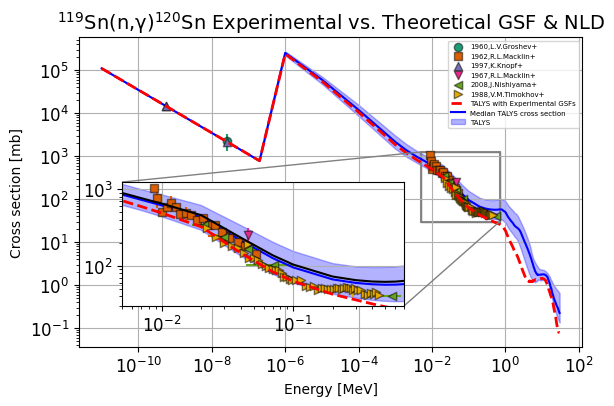

In [516]:
plot_exfor_data(Sn119_n_γ_exfor_data, border_alpha=0.5)
plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, label='TALYS with Experimental GSFs', color='red', linestyle='--', linewidth=2, zorder=4)
plot_TALYS_band(Sn119_n_γ_varying_models)

# Region to zoom
x0, x1 = 5e-3, 7e-1
y0, y1 = 3e1 , 1.25e3

# Draw zoom box on main axes
rect = Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec='gray', lw=1.5, alpha=0.9)
ax = plt.gca()
ax.add_patch(rect)

axins = inset_axes(ax, width="40%", height="40%", loc="upper left", bbox_to_anchor=(0.075, -0.45, 1.4, 1), bbox_transform=ax.transAxes)

# ------------------ Begin Inner Plot ------------------
plt.sca(axins)

plot_exfor_data(Sn119_n_γ_exfor_data, border_alpha=0.5)
plt.plot(Sn119_n_γ_exp_E, Sn119_n_γ_exp_CS, color='red', linestyle='--', linewidth=2, zorder=4)

plot_TALYS_data(Sn119_n_γ, title="", color='black', logx=True)
plot_TALYS_band(Sn119_n_γ_varying_models)

axins.set_xscale('log')
axins.set_yscale('log')
axins.set_xlim(x0, x1)
axins.set_ylim(y0, y1)
axins.grid(True)
axins.get_legend().remove()
axins.set_xlabel('')
axins.set_ylabel('')

plt.sca(ax)
# ------------------- End Inner Plot -------------------

# Connector lines
mark_inset(ax, axins, loc1=2, loc2=4, fc='none', ec='gray', lw=1)

plt.semilogx()
plt.semilogy()

plt.title(r"$^{119}$Sn(n,γ)$^{120}$Sn Experimental vs. Theoretical GSF & NLD")
plt.legend(loc='upper right', fontsize=5)
plt.savefig(fig_dir / 'Sn119_n_gamma_cross_section_varying_models_band_with_exfor_and_experimental_gsf', bbox_inches='tight')
plt.show()